In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn import set_config
set_config(transform_output="pandas")  # keep DataFrame outputs from sklearn transformers

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline

# ---------- Load ----------
# Read the cleaned dataset (produced in Stage 1)
CSV_PATH = "auto_price_cleaned.csv"
df = pd.read_csv(CSV_PATH)

# ---------- Resolve columns ----------
# Helper to normalize names: lowercase + remove non-alphanumeric chars
def _norm(s: str) -> str:
    return "".join(ch for ch in s.lower() if ch.isalnum())

# Given the DataFrame columns and a list of alias candidates,
# return the first alias that appears in the DataFrame (after normalization)
def _resolve(df_cols, aliases):
    norm_map = {_norm(c): c for c in df_cols}
    for cand in aliases:
        k = _norm(cand)
        if k in norm_map:
            return norm_map[k]
    return None

# Candidate aliases for each logical field (to be robust to name variations)
CANDS = {
    "price": ["price","target","sellingprice","listprice","saleprice"],
    "horsepower": ["horsepower","hp","enginepower","powerhp","power_hp"],
    "weight": ["weight","curbweight","curb_weight","vehicleweight","vehweight","mass","weightkg","weight_kg"],
    "engine_size": ["enginesize","engine size","displacement","engine_displacement","engine_cc","enginecc","displacement_cc"],
    "mileage": ["mileage","odometer","km","kilometers","kilometres","kms","miles","distance","mileage_per_year","mileageperyear"],
    "fuel_type": ["fuel type","fuel","fueltype","fuel_kind"],
    "body_type": ["body type","body","bodytype","body_style","bodystyle"],
    "gearing_type": ["gearing_type","transmission","gearbox","transmissiontype","gear_type"],
    "year": ["year","modelyear","registrationyear","firstregyear","manufactureyear"],
    "age": ["age","vehicleage","carage","yearsold"],
}
# Build a mapping from logical names to actual DataFrame columns
resolved = {k: _resolve(df.columns, v) for k, v in CANDS.items()}
print("== Resolved mapping ==")
for k,v in resolved.items(): print(f"{k:>12}: {v}")
print()

# ---------- y, X ----------
# Target: must exist; otherwise raise a clear error
target_col = resolved["price"]
assert target_col is not None, "Price column not found. Update CANDS['price']."

# y: numeric target (coerce non-numeric to NaN)
y = pd.to_numeric(df[target_col], errors="coerce").astype(float)
# X: all predictors except the target column
X = df.drop(columns=[target_col]).copy()

# ---------- Clean y ----------
# Keep only rows where y is finite and non-negative (because we'll use log1p)
mask_y = y.notna() & np.isfinite(y)
mask_y &= (y >= 0)
X = X.loc[mask_y].copy()
y = y.loc[mask_y].copy()
print("After cleaning y:", len(y), "rows; NA:", y.isna().sum(), "; min/max:", y.min(), y.max())

# ---------- Feature engineering ----------
# This function creates additional useful features BEFORE preprocessing.
# It will be applied consistently in both training and testing via a FunctionTransformer.
def engineer_features(g: pd.DataFrame) -> pd.DataFrame:
    g = g.copy()

    # 1) Force key columns to numeric if present
    for logical in ["horsepower","weight","engine_size","mileage","age","year"]:
        real = resolved.get(logical)
        if real in g.columns:
            g[real] = pd.to_numeric(g[real], errors="coerce")

    # 2) Construct 'Age' from 'Year' if no explicit Age, else rename to 'Age'
    age_col = None
    if resolved["age"] is None and resolved["year"] in g.columns:
        g["Age"] = np.clip(datetime.now().year - g[resolved["year"]], 0, None)
        age_col = "Age"
    elif resolved["age"] in g.columns if resolved["age"] else False:
        g.rename(columns={resolved["age"]: "Age"}, inplace=True)
        age_col = "Age"

    # Short handles for frequently used columns
    hp_col = resolved["horsepower"]
    wt_col = resolved["weight"]
    eng_col = resolved["engine_size"]

    # 3) Power-to-weight ratio (robust to invalid/zero weight)
    if hp_col in g.columns and wt_col in g.columns:
        denom = np.where((g[wt_col] <= 0) | g[wt_col].isna(), np.nan, g[wt_col])
        g["power_to_weight"] = g[hp_col] / denom

    # 4) Interaction features (capture nonlinear relationships)
    if hp_col in g.columns and wt_col in g.columns:
        g["hp_weight_interaction"] = g[hp_col] * g[wt_col]
    if hp_col in g.columns and eng_col in g.columns:
        g["hp_engine_interaction"] = g[hp_col] * g[eng_col]
    if hp_col in g.columns and (age_col in g.columns if age_col else False):
        g["hp_age_ratio"] = g[hp_col] / (g["Age"] + 1)

    # 5) Log-scale mileage to reduce right skew
    mil_col = resolved["mileage"]
    if mil_col in g.columns:
        g["log_mileage"] = np.log1p(np.clip(g[mil_col], a_min=0, a_max=None))

    # 6) Bin horsepower to create a categorical banded feature
    if hp_col in g.columns:
        bins = [0, 80, 120, 160, 220, 320, 10000]
        g["hp_bin"] = pd.cut(g[hp_col], bins=bins, labels=False, include_lowest=True)

    return g

# Wrap the function so it integrates in sklearn Pipelines
fe_transformer = FunctionTransformer(engineer_features, validate=False)

# ---------- Columns for preprocess ----------
# Numeric columns go through median imputation
NUM_COLS = [c for c in [
    resolved["horsepower"], resolved["weight"], resolved["engine_size"], resolved["mileage"],
    "power_to_weight", "hp_weight_interaction", "hp_engine_interaction", "hp_age_ratio",
    "log_mileage", "Age"
] if c is not None]

# Categorical columns go through most-frequent imputation + one-hot encoding
CAT_COLS = [c for c in [resolved["fuel_type"], resolved["body_type"], resolved["gearing_type"], "hp_bin"] if c is not None]

# Impute + Encode/Pass
# ColumnTransformer applies different pipelines to numeric vs categorical subsets
preprocess = ColumnTransformer(
    transformers=[
        ("cat", SkPipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), CAT_COLS),
        ("num", SkPipeline([
            ("impute", SimpleImputer(strategy="median"))
        ]), NUM_COLS),
    ],
    remainder="drop"  # drop any columns not listed above
)

# ---------- Pipeline + log-target ----------
USE_LOG_TARGET = True
tree_base = DecisionTreeRegressor(random_state=42)

# End-to-end pipeline:
# 1) feature engineering -> 2) preprocessing -> 3) decision tree
pipe_tree = Pipeline([
    ("fe", fe_transformer),
    ("prep", preprocess),
    ("model", tree_base)
])

# Apply log1p to y during fit, and expm1 to predictions automatically
model_tree = TransformedTargetRegressor(regressor=pipe_tree, func=np.log1p, inverse_func=np.expm1) if USE_LOG_TARGET else pipe_tree

# ---------- Split + Grid ----------
# Hold-out split for final evaluation; GridSearchCV uses only the training fold
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Hyperparameter grid for DecisionTreeRegressor (wrapped inside TTR)
param_grid = {
    ("regressor__model__max_depth" if USE_LOG_TARGET else "model__max_depth"): [6, 8, 10, 12, 14],
    ("regressor__model__min_samples_leaf" if USE_LOG_TARGET else "model__min_samples_leaf"): [10, 20, 30, 50],
    ("regressor__model__min_samples_split" if USE_LOG_TARGET else "model__min_samples_split"): [2, 10, 20],
    ("regressor__model__max_features" if USE_LOG_TARGET else "model__max_features"): [None, "sqrt", "log2"],
}

# 5-fold CV with shuffling for a reliable estimate
cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(estimator=model_tree, param_grid=param_grid, scoring="r2", cv=cv, n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
best_tree = grid.best_estimator_

# ---------- Evaluate ----------
# Predict on the untouched test set and compute regression metrics
y_pred = best_tree.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("== Decision Tree (clean y + imputers) ==")
print("Best params:", grid.best_params_)
print(f"MAE  = {mae:,.2f}")
print(f"RMSE = {rmse:,.2f}")
print(f"R²   = {r2:.4f}")

== Resolved mapping ==
       price: Price
  horsepower: Horsepower
      weight: Weight
 engine_size: Displacement
     mileage: Mileage
   fuel_type: Fuel
   body_type: Body_Type
gearing_type: Gearing_Type
        year: None
         age: Age

After cleaning y: 8107 rows; NA: 0 ; min/max: 4950.0 259454.3395
== Decision Tree (clean y + imputers) ==
Best params: {'regressor__model__max_depth': 14, 'regressor__model__max_features': None, 'regressor__model__min_samples_leaf': 10, 'regressor__model__min_samples_split': 2}
MAE  = 2,012.83
RMSE = 3,080.24
R²   = 0.8066


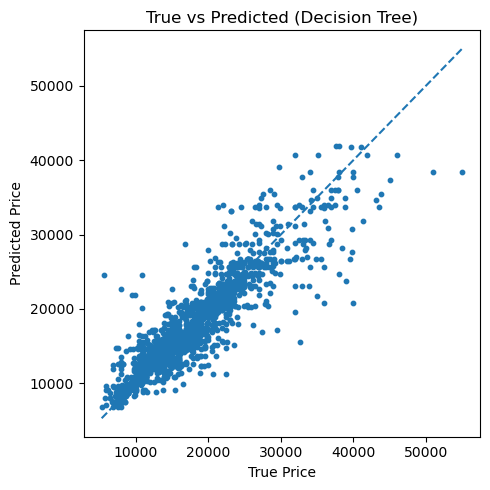

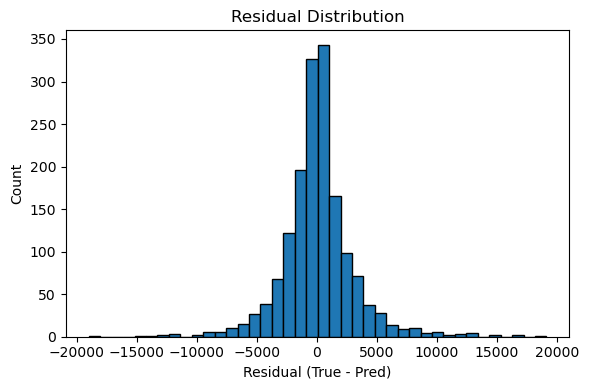

In [2]:
# === Plot: True vs Predicted & Residuals ===
import matplotlib.pyplot as plt
import numpy as np

# 1) True vs Predicted
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, s=10)
mn, mx = float(np.min(y_test)), float(np.max(y_test))
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("True vs Predicted (Decision Tree)")
plt.tight_layout()
plt.show()

# 2) Residual histogram
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=40, edgecolor="k")
plt.xlabel("Residual (True - Pred)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()


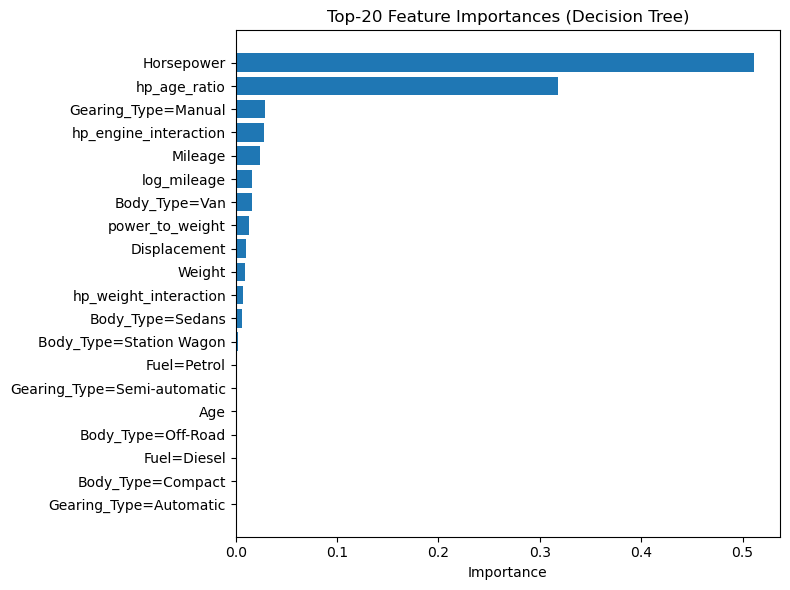

,feature,importance
23,Horsepower,0.511418
30,hp_age_ratio,0.318132
15,Gearing_Type=Manual,0.028517
29,hp_engine_interaction,0.028217
26,Mileage,0.024263
31,log_mileage,0.016490
13,Body_Type=Van,0.015906
27,power_to_weight,0.012636
25,Displacement,0.010028
24,Weight,0.009096


In [3]:
# === Top-20 Feature Importances with readable names ===
import pandas as pd

# 1) access the inner fitted pipeline & model
inner = best_tree.regressor_ if hasattr(best_tree, "regressor_") else best_tree
prep  = inner.named_steps["prep"]
model = inner.named_steps["model"]     # DecisionTreeRegressor

# 2) build feature names (OHE cat names like "Fuel=Diesel" + numeric names)
cat_names = []
if len(CAT_COLS) > 0 and "cat" in prep.named_transformers_:
    ohe = prep.named_transformers_["cat"].named_steps["ohe"]
    # match each original categorical column to its learned categories
    for col, cats in zip(CAT_COLS, ohe.categories_):
        cat_names += [f"{col}={c}" for c in cats]

num_names = NUM_COLS
feature_names = cat_names + num_names

# 3) align importances
importances = model.feature_importances_
fi = pd.DataFrame({"feature": feature_names, "importance": importances}) \
       .sort_values("importance", ascending=False).head(20)

# 4) bar plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.barh(fi["feature"][::-1], fi["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top-20 Feature Importances (Decision Tree)")
plt.tight_layout()
plt.show()

fi.head(10)


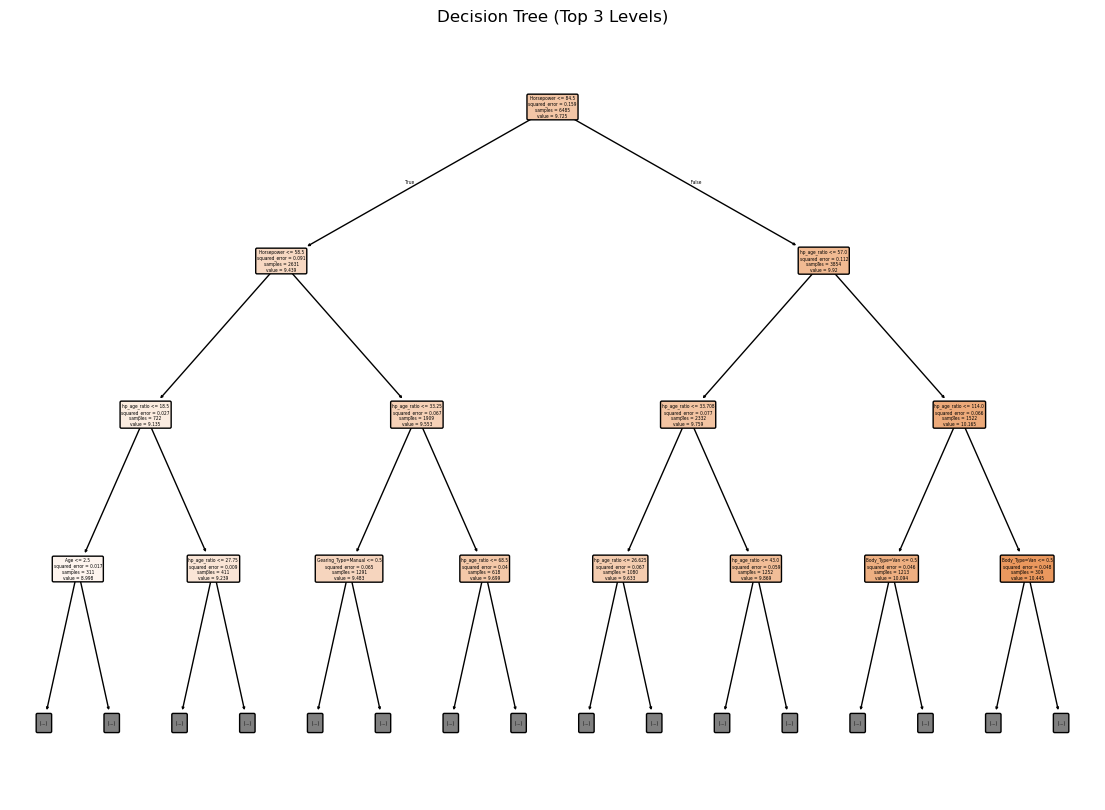

In [4]:
# === Shallow Tree Visualization (top 3 levels) ===
from sklearn.tree import plot_tree

plt.figure(figsize=(14,10))
plot_tree(
    model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    impurity=True,
    max_depth=3   # show only top 3 levels for readability
)
plt.title("Decision Tree (Top 3 Levels)")
plt.show()
